<a href="https://colab.research.google.com/github/GermanOmar/TensileTest_PAFC/blob/master/PAFC_NM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Effect of Tensile Testing Parameters on the Mechanical Performance of Poulsenia Armata Fiber Cloth: Experimental Analysis and Machine Learning Modeling

## Libraries

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn import preprocessing
import warnings
warnings.filterwarnings("ignore")

In [2]:
#---------Scikit-learn Utilities---------------------------------------------------------------------------------------------
from sklearn.metrics import r2_score as R2
from sklearn import preprocessing
from sklearn.metrics import mean_absolute_error as MAE
from sklearn.metrics import mean_squared_error as MSE
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor

In [3]:
pip install nbformat


In [4]:
!pip install lazypredict
warnings.filterwarnings("ignore")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 1.9 MB/s eta 0:00:00


## Upload database:

In [5]:
!git clone https://github.com/GermanOmar/TensileTest_PAFC

Cloning into 'TensileTest_PAFC'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.


In [6]:
#Experimental data
data = pd.read_table('/content/TensileTest_PAFC/UTS.txt')
data.describe()

,GL,CHS,UTS
count,90.000000,90.000000,90.000000
mean,50.000000,5.833333,21.774444
std,20.526771,3.135516,5.263269
min,25.000000,2.500000,13.170000
25%,25.000000,2.500000,17.327500
50%,50.000000,5.000000,21.145000
75%,75.000000,10.000000,24.890000
max,75.000000,10.000000,33.980000


In [7]:
df = data.copy()
df.head()

,GL,CHS,UTS
0,25,2.5,19.91
1,25,2.5,19.33
2,25,2.5,24.83
3,25,2.5,22.43
4,25,2.5,23.12


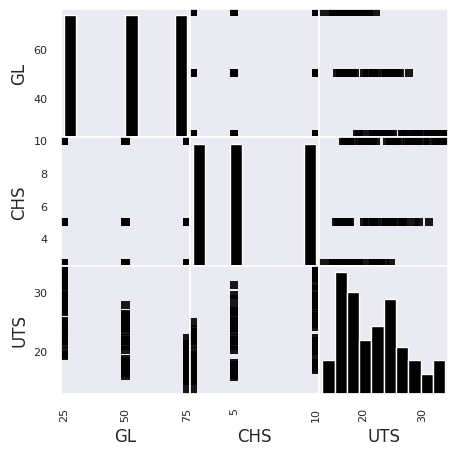

In [8]:
from pandas.plotting import scatter_matrix
#DISPLAY MATRIX - identificar correlacion entre variables
import seaborn as sns
sns.set()

plt.rcParams["axes.grid"] = False

#pd.tools.plotting.scatter_matrix(df, alpha=0.2, c='red', hist_kwds={'color':['burlywood']})

#scatter_matrix(data, alpha=0.2, marker='o', figsize = (12,12), color = 'blue')
scatter_matrix(data, alpha=0.9,marker='s', figsize = (5,5),  c='black', hist_kwds={'color':['black']})

warnings.filterwarnings("ignore")

##Setting inputs - output:

In [9]:
X=data[['GL', 'CHS']]
Y=data['UTS'].values.reshape(-1, 1)


## Split data

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=0)
print('training samples:', X_train.shape[0],  ' test samples:', X_test.shape[0])

training samples: 72  test samples: 18


In [11]:
YTR=np.mean(y_train)
YTR

np.float64(21.76625)

In [12]:
YT=np.mean(y_test)
YT

np.float64(21.807222222222222)

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
from lazypredict.Supervised import LazyRegressor
from sklearn.utils import shuffle

In [15]:
from sklearn.metrics import mean_absolute_error as MAE
reg = LazyRegressor(verbose=0,ignore_warnings=False, custom_metric=None)
models,predictions = reg.fit(X_train, X_test, y_train, y_test)

print(models)

                               Adjusted R-Squared  R-Squared       RMSE  \
Model                                                                     
KNeighborsRegressor                      0.856478   0.873363   1.906006   
RandomForestRegressor                    0.845547   0.863718   1.977259   
ExtraTreesRegressor                      0.844487   0.862783   1.984033   
DecisionTreeRegressor                    0.844487   0.862783   1.984033   
ExtraTreeRegressor                       0.844487   0.862783   1.984033   
GaussianProcessRegressor                 0.844487   0.862782   1.984034   
XGBRegressor                             0.844485   0.862781   1.984043   
GradientBoostingRegressor                0.844458   0.862757   1.984216   
BaggingRegressor                         0.838690   0.857668   2.020671   
AdaBoostRegressor                        0.825556   0.846079   2.101323   
PoissonRegressor                         0.811858   0.833992   2.182269   
OrthogonalMatchingPursuit

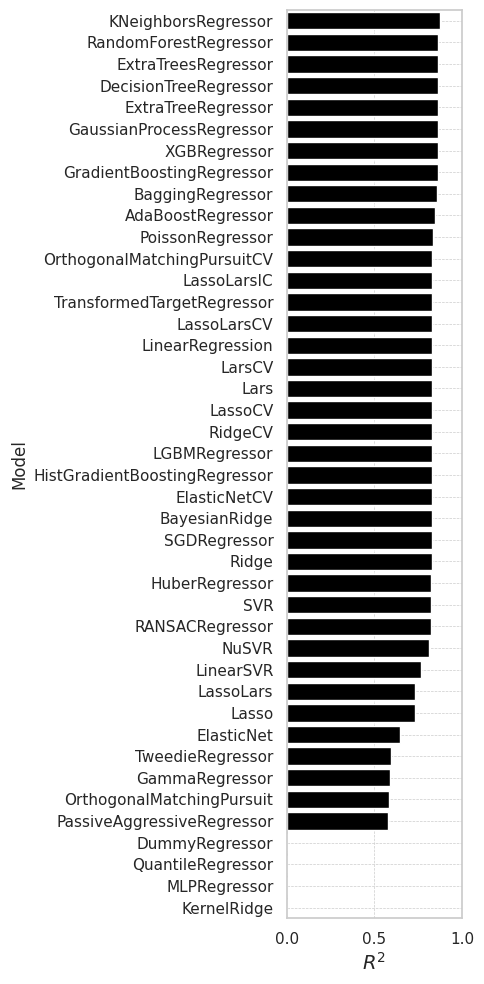

In [16]:
# Plotting
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11

import seaborn as sns

plt.style.use('seaborn-v0_8-white')
#palette = sns.color_palette("crest", len(mi_df))

import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.family'] = 'serif'
plt.style.use('seaborn-v0_8-white')
#palette = sns.color_palette("crest", len(mi_df))
sns.set_theme(style="whitegrid")

# Corrected to use 'models' DataFrame and apply filtering to 'R-Squared'
models["R-Squared_filtered"] = [0 if i < 0 else i for i in models["R-Squared"] ]
plt.figure(figsize=(5, 10))
#palette = sns.color_palette("flare", len(corr_df))
ax = sns.barplot(y=models.index, x="R-Squared_filtered", data=models, color='black') # Changed to use 'models' and the new filtered column
ax.set(xlim=(0, 1))
plt.xlabel('$R^2$', fontsize=14)

plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()

plt.savefig('lazy1.png', dpi=300)

plt.show()

# KNN


In [17]:
from sklearn.neighbors import KNeighborsRegressor
#KERNEL
KNN=KNeighborsRegressor(n_neighbors=7)

#START TRAINING
KNN.fit(X_train,y_train)
#PREDICTION

y_train_pred = KNN.predict(X_train)
y_test_pred = KNN.predict(X_test)

y_pred_train = KNN.predict(X_train)
y_pred_test = KNN.predict(X_test)

MSE_train = MSE(y_train, y_train_pred)
MSE_test = MSE(y_test, y_test_pred)
r2_train = R2(y_train, y_train_pred)
r2_test = R2(y_test, y_test_pred)
mae_train = MAE(y_train, y_train_pred)
mae_test = MAE(y_test, y_test_pred)

print('-'*100)
print(f'Error Metrics')
print(f'Training: MAE={mae_train:.4f}, MSE={MSE_train:.4f}, R2={r2_train:.4f}')
print(f'Testing: MAE={mae_test:.4f}, MSE={MSE_test:.4f}, R2={r2_test:.4f}')
print('-'*100)

----------------------------------------------------------------------------------------------------
Error Metrics
Training: MAE=1.4512, MSE=3.3676, R2=0.8756
Testing: MAE=1.8066, MSE=4.0587, R2=0.8585
----------------------------------------------------------------------------------------------------


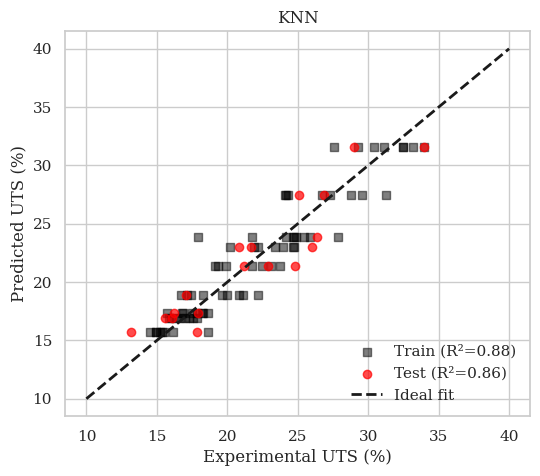

In [18]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11

fig, axes = plt.subplots(1, 1, figsize=(6, 5), sharex=True, sharey=True)

ax = axes
ax.scatter(y_train, y_pred_train, label=f"Train (R²={r2_train:.2f})", alpha=0.5, color='black', marker='s')
ax.scatter(y_test, y_pred_test, label=f"Test (R²={r2_test:.2f})", alpha=0.7, color='red')
#ax.plot([190, 260], [190, 260], 'k--', lw=2, label='Ideal fit')
ax.plot([10, 40], [10, 40], 'k--', lw=2, label='Ideal fit')

ax.set_title("KNN")
ax.set_xlabel("Experimental UTS (%)")
ax.set_ylabel("Predicted UTS (%)")


ax.legend(loc='lower right')

plt.show()

# Random Forest Regressor

In [19]:
from sklearn.ensemble import RandomForestRegressor
#KERNEL
RFR=RandomForestRegressor(n_estimators=2000)

#START TRAINING
RFR.fit(X_train,y_train)
#PREDICTION

y_train_pred = RFR.predict(X_train)
y_test_pred = RFR.predict(X_test)

y_pred_train = RFR.predict(X_train)
y_pred_test = RFR.predict(X_test)

MSE_train = MSE(y_train, y_train_pred)
MSE_test = MSE(y_test, y_test_pred)
r2_train = R2(y_train, y_train_pred)
r2_test = R2(y_test, y_test_pred)
mae_train = MAE(y_train, y_train_pred)
mae_test = MAE(y_test, y_test_pred)

print('-'*100)
print(f'Error Metrics')
print(f'Training: MAE={mae_train:.4f}, MSE={MSE_train:.4f}, R2={r2_train:.4f}')
print(f'Testing: MAE={mae_test:.4f}, MSE={MSE_test:.4f}, R2={r2_test:.4f}')
print('-'*100)

----------------------------------------------------------------------------------------------------
Error Metrics
Training: MAE=1.4203, MSE=3.3114, R2=0.8777
Testing: MAE=1.7493, MSE=3.9297, R2=0.8630
----------------------------------------------------------------------------------------------------


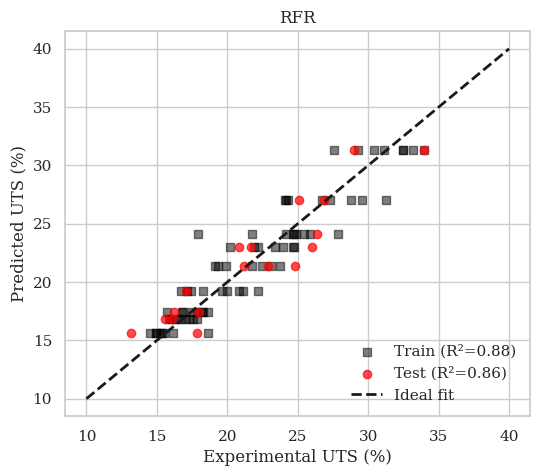

In [20]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11

fig, axes = plt.subplots(1, 1, figsize=(6, 5), sharex=True, sharey=True)

ax = axes
ax.scatter(y_train, y_pred_train, label=f"Train (R²={r2_train:.2f})", alpha=0.5, color='black', marker='s')
ax.scatter(y_test, y_pred_test, label=f"Test (R²={r2_test:.2f})", alpha=0.7, color='red')
#ax.plot([190, 260], [190, 260], 'k--', lw=2, label='Ideal fit')
ax.plot([10, 40], [10, 40], 'k--', lw=2, label='Ideal fit')

ax.set_title("RFR")
ax.set_xlabel("Experimental UTS (%)")
ax.set_ylabel("Predicted UTS (%)")


ax.legend(loc='lower right')

plt.show()

# MLP

In [21]:
from sklearn.neural_network import MLPRegressor

MLP =MLPRegressor(activation='relu', alpha=0.0001, batch_size='auto', beta_1=0.9,
             beta_2=0.999, early_stopping=False, epsilon=1e-08,
             hidden_layer_sizes=4, learning_rate='adaptive',
             learning_rate_init=0.001, max_fun=15000, max_iter=1000,
             momentum=0.9, n_iter_no_change=10, nesterovs_momentum=True,
             power_t=0.5, random_state=4321, shuffle=True, solver='lbfgs',
             tol=0.0001, validation_fraction=0.1, verbose=False,
             warm_start=False)
#MLP = MLPRegressor(hidden_layer_sizes=(1000,1000,1000), activation='relu', solver='adam', max_iter=800)

#START TRAINING
MLP.fit(X_train,y_train)
#PREDICTION
y_pred=MLP.predict(X_test)



In [22]:
y_pred_train = MLP.predict(X_train)
y_pred_test = MLP.predict(X_test)

mse_train = MSE(y_train, y_pred_train)
mse_test = MSE(y_test, y_pred_test)
r2_train = R2(y_train, y_pred_train)
r2_test = R2(y_test, y_pred_test)
mae_train = MAE(y_train, y_pred_train)
mae_test = MAE(y_test, y_pred_test)

print('-'*100)
print(f'Error Metrics')
print(f'Training: MAE={mae_train:.4f}, MSE={mse_train:.4f}, R2={r2_train:.4f}')
print(f'Testing: MAE={mae_test:.4f}, MSE={mse_test:.4f}, R2={r2_test:.4f}')
print('-'*100)

----------------------------------------------------------------------------------------------------
Error Metrics
Training: MAE=1.6025, MSE=4.2802, R2=0.8419
Testing: MAE=1.7141, MSE=4.2990, R2=0.8501
----------------------------------------------------------------------------------------------------


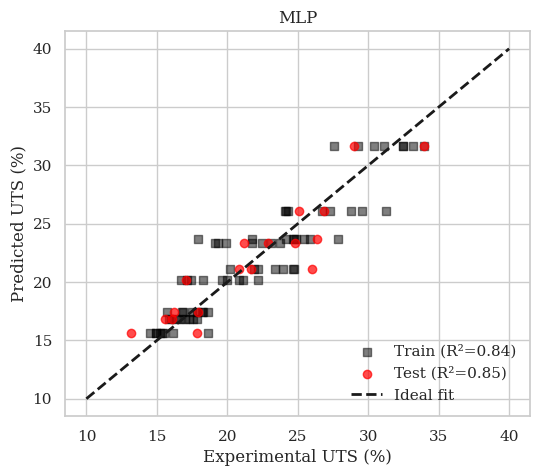

In [23]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11

fig, axes = plt.subplots(1, 1, figsize=(6, 5), sharex=True, sharey=True)

ax = axes
ax.scatter(y_train, y_pred_train, label=f"Train (R²={r2_train:.2f})", alpha=0.5, color='black', marker='s')
ax.scatter(y_test, y_pred_test, label=f"Test (R²={r2_test:.2f})", alpha=0.7, color='red')
ax.plot([10, 40], [10, 40], 'k--', lw=2, label='Ideal fit')

ax.set_title("MLP")
ax.set_xlabel("Experimental UTS (%)")
ax.set_ylabel("Predicted UTS (%)")


ax.legend(loc='lower right')

plt.show()

# Gaussian Process Regressor

In [24]:
from sklearn.gaussian_process import GaussianProcessRegressor as GPR
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
kernel = C(1.0, (1e-2, 1e2)) * RBF(10, (1e-2, 1e2))

GP=GPR(kernel=kernel, n_restarts_optimizer=20, alpha=0.001, normalize_y=True)

#START TRAINING
GP.fit(X_train, y_train)
#PREDICTION
y_train_pred = GP.predict(X_train)
y_test_pred = GP.predict(X_test)

y_pred_train = GP.predict(X_train)
y_pred_test = GP.predict(X_test)

MSE_train = MSE(y_train, y_train_pred)
MSE_test = MSE(y_test, y_test_pred)
r2_train = R2(y_train, y_train_pred)
r2_test = R2(y_test, y_test_pred)
mae_train = MAE(y_train, y_train_pred)
mae_test = MAE(y_test, y_test_pred)

print('-'*100)
print(f'Error Metrics')
print(f'Training: MAE={mae_train:.4f}, MSE={MSE_train:.4f}, R2={r2_train:.4f}')
print(f'Testing: MAE={mae_test:.4f}, MSE={MSE_test:.4f}, R2={r2_test:.4f}')
print('-'*100)

----------------------------------------------------------------------------------------------------
Error Metrics
Training: MAE=1.4195, MSE=3.3112, R2=0.8777
Testing: MAE=1.7534, MSE=3.9370, R2=0.8628
----------------------------------------------------------------------------------------------------


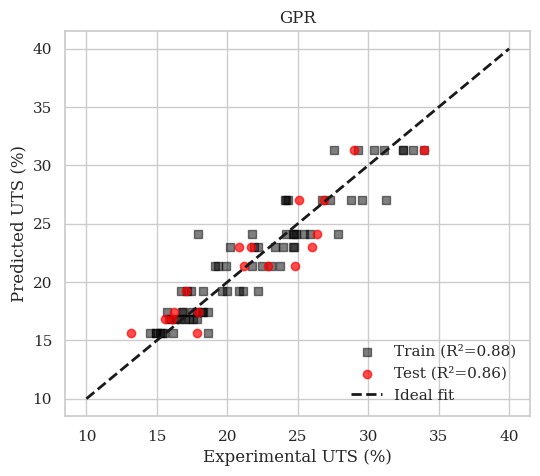

In [25]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11

fig, axes = plt.subplots(1, 1, figsize=(6, 5), sharex=True, sharey=True)

ax = axes
ax.scatter(y_train, y_pred_train, label=f"Train (R²={r2_train:.2f})", alpha=0.5, color='black', marker='s')
ax.scatter(y_test, y_pred_test, label=f"Test (R²={r2_test:.2f})", alpha=0.7, color='red')
ax.plot([10, 40], [10, 40], 'k--', lw=2, label='Ideal fit')

ax.set_title("GPR")
ax.set_xlabel("Experimental UTS (%)")
ax.set_ylabel("Predicted UTS (%)")


ax.legend(loc='lower right')

plt.show()

# Cross-validation

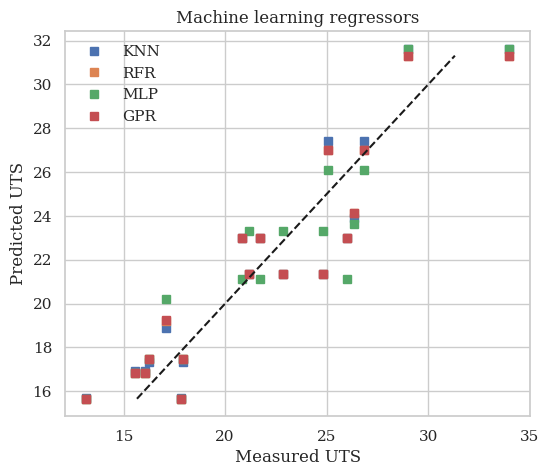

In [26]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11

y1=KNN.predict(X_test)
y2=RFR.predict(X_test)
y3=MLP.predict(X_test)
y4=GP.predict(X_test)

#Plots
models = [ KNN, RFR, MLP, GP]
labels = ['KNN', 'RFR',  'MLP', 'GPR']

fig = plt.figure()
fig.set_size_inches((6,5))

for mod, label in zip( models, labels):
  y_pred = mod.predict(X_test)
  plt.plot(y_test, y_pred, 's' ,label = label)

plt.plot([y_pred.min(), y_pred.max()], [y_pred.min(), y_pred.max()], 'k--')



plt.legend()
plt.ylabel('Predicted UTS')
plt.xlabel('Measured UTS')
plt.title("Machine learning regressors")
print()

In [27]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error as MSE
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import cross_val_score as CV

import warnings
warnings.filterwarnings('ignore')

models = [ KNN, RFR, MLP, GP]
labels = ['KNN', 'RFR',  'MLP', 'GPR']
IMS = []

print("--------------------------------------------------------------")
print("%15s | %8s | %8s | %8s" % ("ML algorithm",  "CV-R2", "CV-MSE", "CV-MAE"))
print("--------------------------------------------------------------")

for mod, label in zip( models, labels):
  y_star_train = mod.predict(X_train)

  scoreR2 = CV(mod, X_train, y_train, cv=5, scoring='r2')
  #print(-1*scoreR2)
  scoreMSE = CV(mod, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
  #print(-1*scoreMSE)
  scoreMAE = CV(mod, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
  #print(-1*scoreMAE)

  print("%15s | %.4f | %.4f | %.4f" % (label,  scoreR2.mean(), -1*scoreMSE.mean(), -1*scoreMAE.mean() ))
print("--------------------------------------------------------------")

--------------------------------------------------------------
   ML algorithm |    CV-R2 |   CV-MSE |   CV-MAE
--------------------------------------------------------------
            KNN | 0.7059 | 7.0843 | 1.9942
            RFR | 0.8028 | 4.4323 | 1.6289
            MLP | 0.7601 | 5.4433 | 1.7942
            GPR | 0.8035 | 4.4177 | 1.6289
--------------------------------------------------------------


# LOO

In [28]:
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ----------------------------------------
# Assume your flex dataset is defined as:
# X = np.array([...]).reshape(-1, 1)  # TiO2 wt.%
# y = np.array([...])                 # Flexural strength (MPa)
# ----------------------------------------

loo = LeaveOneOut()

# Fix: Create a dictionary for models using labels and the models list
models_dict = dict(zip(labels, models))

results = {}

for name, model in models_dict.items():
    y_true = []
    y_pred = []

    for train_idx, test_idx in loo.split(X):

        # Split data
        X_train_loo, X_test_loo = X.iloc[train_idx], X.iloc[test_idx]
        y_train_loo, y_test_loo = Y[train_idx], Y[test_idx]

        # Standardize INSIDE CV loop (avoid leakage)
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_loo)
        X_test_scaled = scaler.transform(X_test_loo)

        # Fit model
        # Reshape y_train_loo to be 1D for models like MLPRegressor
        if y_train_loo.ndim > 1 and y_train_loo.shape[1] == 1:
            model.fit(X_train_scaled, y_train_loo.ravel())
        else:
            model.fit(X_train_scaled, y_train_loo)

        # Predict
        prediction = model.predict(X_test_scaled)

        y_true.append(y_test_loo[0])
        y_pred.append(prediction[0])

    # Convert to arrays
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Metrics
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    results[name] = {"MAE": mae, "MSE": mse, "R2": r2}

# Print results
for model_name, metrics in results.items():
    print(f"{model_name} LOOCV Results:")
    print(f"  MAE: {metrics['MAE']:.3f}")
    print(f"  MSE: {metrics['MSE']:.3f}")
    print(f"  R2 : {metrics['R2']:.3f}")
    print("-" * 40)


KNN LOOCV Results:
  MAE: 1.678
  MSE: 4.355
  R2 : 0.841
----------------------------------------
RFR LOOCV Results:
  MAE: 1.622
  MSE: 4.185
  R2 : 0.847
----------------------------------------
MLP LOOCV Results:
  MAE: 1.590
  MSE: 4.102
  R2 : 0.850
----------------------------------------
GPR LOOCV Results:
  MAE: 1.621
  MSE: 4.184
  R2 : 0.847
----------------------------------------
